In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [3]:
df = pd.read_csv('/Users/mjablons/Documents/spice/tutorial/paper_results/ab_dor/data/ASASSN-V J052845.01-652656.6.csv')
df.head()

,hjd,camera,mag,mag_err,flux,flux_err
0,2.457063e+06,be,7.584,0.02,3817.294,70.238
1,2.457390e+06,bh,7.600,0.02,3497.402,64.352
2,2.457783e+06,bh,7.644,0.02,3361.148,61.845
3,2.456980e+06,bf,7.454,0.02,4017.955,73.930
4,2.457086e+06,be,7.618,0.02,3700.851,68.096


In [4]:
df.camera.unique()

array(['be', 'bh', 'bf', 'bg'], dtype=object)

In [5]:
be = df[df.camera == 'be']
bh = df[df.camera == 'bh']
bf = df[df.camera == 'bf']
bg = df[df.camera == 'bg']

In [8]:
from astropy.stats import sigma_clip

def sigma_clip_flux(df):
    # Example: assume df has columns 'flux' or 'mag'
    flux = df['flux'].values  # or 'mag'

    clipped = sigma_clip(
        flux,
        sigma=3,           # 3σ clipping
        maxiters=5,        # iterate until convergence
        cenfunc='median',  # robust center
        stdfunc='mad_std'  # robust scatter
    )

    # Masked array → keep only good points
    clean_flux = flux[~clipped.mask]
    clean_df = df[~clipped.mask]
    return clean_df

<ErrorbarContainer object of 3 artists>

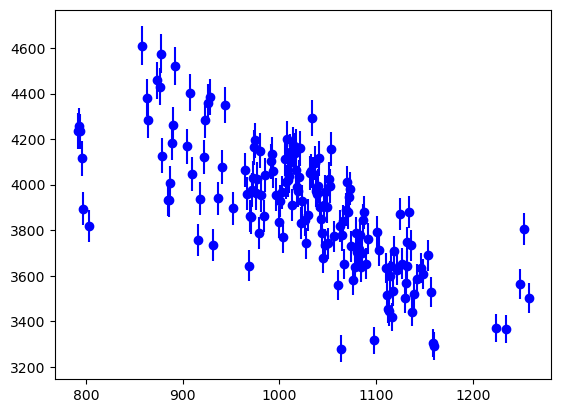

In [13]:
clean_be = sigma_clip_flux(be)
plt.errorbar(clean_be.hjd-2456000, clean_be.flux, yerr=clean_be.flux_err, fmt='o', label='BE', color='blue')

<ErrorbarContainer object of 3 artists>

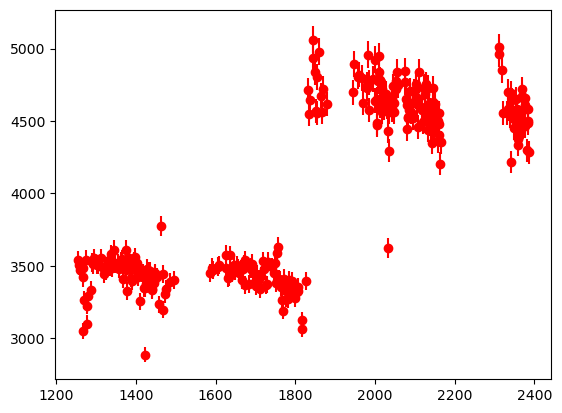

In [15]:
clean_bh = sigma_clip_flux(bh)
plt.errorbar(clean_bh.hjd-2456000, clean_bh.flux, yerr=clean_bh.flux_err, fmt='o', label='BH', color='red')


<ErrorbarContainer object of 3 artists>

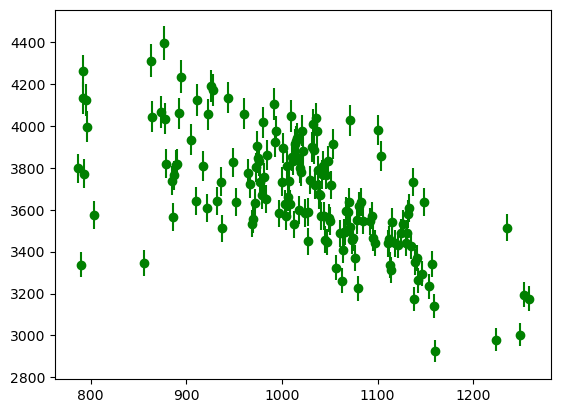

In [16]:
clean_bf = sigma_clip_flux(bf)
plt.errorbar(clean_bf.hjd-2456000, clean_bf.flux, yerr=clean_bf.flux_err, fmt='o', label='BF', color='green')

<ErrorbarContainer object of 3 artists>

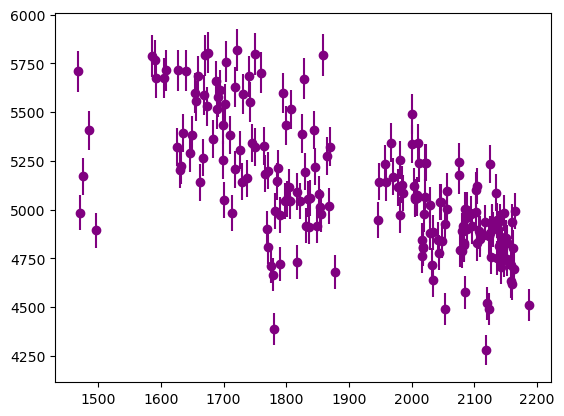

In [17]:
clean_bg = sigma_clip_flux(bg)
plt.errorbar(clean_bg.hjd-2456000, clean_bg.flux, yerr=clean_bg.flux_err, fmt='o', label='BG', color='purple')

# TESS photometry

# TESS photometry

In [21]:
import lightkurve as lk
import numpy as np

TIC_ID = "TIC 149622009"

# -------------------------------------------------
# 1. Download all available TESS light curves
# -------------------------------------------------
lc_collection = lk.search_lightcurve(
    TIC_ID,
    mission="TESS"
).download_all()

print(lc_collection)

LightCurveCollection of 6 objects:
    0: <TessLightCurve LABEL="TIC 149622009" SECTOR=23 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 149622009" SECTOR=50 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 149622009" SECTOR=23 AUTHOR=TESS-SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 149622009" SECTOR=50 AUTHOR=TESS-SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 149622009" SECTOR=23 AUTHOR=QLP FLUX_ORIGIN=sap_flux>
    5: <TessLightCurve LABEL="TIC 149622009" SECTOR=50 AUTHOR=QLP FLUX_ORIGIN=sap_flux>


<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

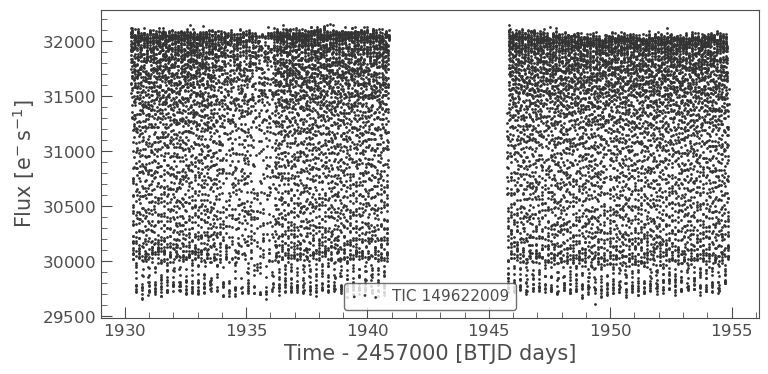

In [22]:
lc_collection[0].scatter()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

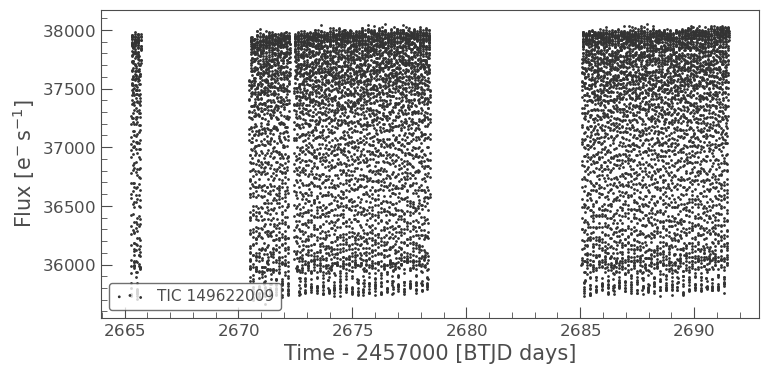

In [23]:
lc_collection[1].scatter()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

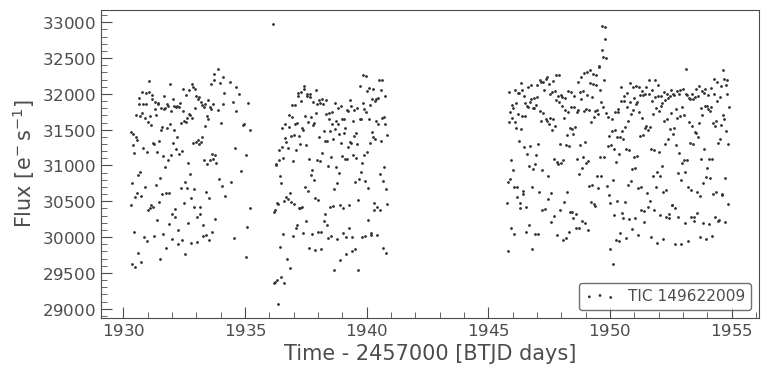

In [24]:
lc_collection[2].scatter()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

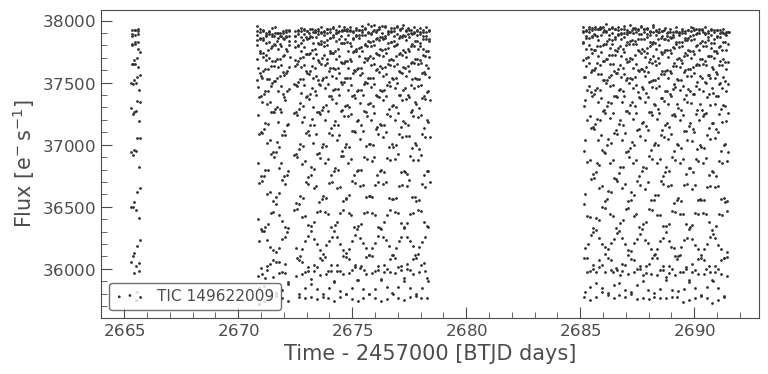

In [25]:
lc_collection[3].scatter()